       iOS XNU PROCESS ARCHITECTURE SIMULATOR        

--- Configuring Process 1 ---
Select QoS Class: 1) User Interactive  2) User Initiated  3) Utility  4) Background

--- Configuring Process 2 ---
Select QoS Class: 1) User Interactive  2) User Initiated  3) Utility  4) Background
             LAUNCHD RUNTIME AND SCHEDULING LOG            
[Time 00s] CPU Core Idle.
[Time 01s] CPU Core Idle.
[Time 02s] CPU Core Idle.
[Time 03s] launchd spawned 'safari' -> Ready Queue.
[Time 03s] Running: 'safari' [User Interactive] (Rem: 5s)
[Time 04s] Running: 'safari' [User Interactive] (Rem: 4s)
[Time 05s] launchd spawned 'music' -> Ready Queue.
[Time 05s] Running: 'safari' [User Interactive] (Rem: 3s)
[Time 06s] Running: 'safari' [User Interactive] (Rem: 2s)
[Time 07s] Running: 'safari' [User Interactive] (Rem: 1s)
[Time 08s] Finished: 'safari' -> Suspended State.
[Time 08s] Running: 'music' [Utility] (Rem: 6s)
[Time 09s] Running: 'music' [Utility] (Rem: 5s)
[Time 10s] Running: 'music' [Utility] (

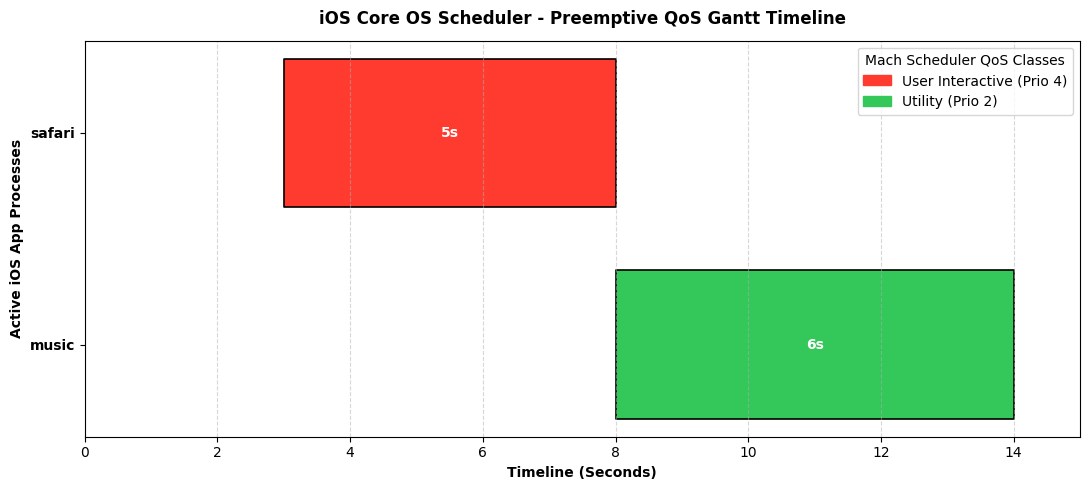

In [1]:
import matplotlib.pyplot as plt
import random

# iOS QoS Priority Configuration: Higher number=Higher priority
QOS_LEVELS = {
    1: {"name": "User Interactive", "priority": 4, "color": "#FF3B30"}, 
    2: {"name": "User Initiated",   "priority": 3, "color": "#FF9500"}, 
    3: {"name": "Utility",          "priority": 2, "color": "#34C759"}, 
    4: {"name": "Background",       "priority": 1, "color": "#5856D6"}  
}

class iOSProcess:
    def __init__(self, pid, name, arrival, burst, qos_choice):
        self.pid, self.name, self.arrival_time, self.burst_time, self.remaining_time = pid, name, arrival, burst, burst
        qos = QOS_LEVELS.get(qos_choice, QOS_LEVELS[4])
        self.qos_name, self.priority, self.color = qos["name"], qos["priority"], qos["color"]
        self.start_time, self.completion_time, self.current_state, self.pipeline_history = -1, 0, "Not Running", []

    def update_state(self, timestamp, new_state, detail=""):
        self.current_state = new_state
        msg = f"Time {timestamp:02d}s | State: {new_state:<10}"
        self.pipeline_history.append(msg + (f" -> {detail}" if detail else ""))

def get_user_input():
    print("       iOS XNU PROCESS ARCHITECTURE SIMULATOR        " )
    try:
        num = int(input("Enter number of processes to simulate: "))
    except ValueError:
        num = 3

    processes = []
    for i in range(num):
        print(f"\n--- Configuring Process {i + 1} ---")
        name = input("Enter Application Name: ") or f"App_{i+1}"
        try:
            arr = int(input(f"Enter Arrival Time for {name} (Seconds >= 0): "))
            bst = int(input(f"Enter Burst Time for {name} (Seconds > 0): "))
        except ValueError:
            arr, bst = i * 2, random.randint(3, 7)
            
        print("Select QoS Class: 1) User Interactive  2) User Initiated  3) Utility  4) Background")
        try:
            qos = int(input("Choice (1-4): "))
        except ValueError:
            qos = 4
            
        proc = iOSProcess(i, name, arr, bst, qos)
        proc.update_state(0, "Not Running", "App initialized.")
        processes.append(proc)
    return processes

def run_simulation(processes):
    print("             LAUNCHD RUNTIME AND SCHEDULING LOG            ")
    current_time, completed, n, gantt_log, last_run_pid, chunk_start = 0, 0, len(processes), [], None, 0
    
    while completed < n:
        for p in processes:
            if p.arrival_time == current_time and p.current_state == "Not Running":
                p.update_state(current_time, "Ready", "Registered in ready queue.")
                print(f"[Time {current_time:02d}s] launchd spawned '{p.name}' -> Ready Queue.")

        available = [p for p in processes if p.arrival_time <= current_time and p.remaining_time > 0]
        
        if not available:
            if last_run_pid is not None:
                prev = next(p for p in processes if p.pid == last_run_pid)
                gantt_log.append((prev.name, chunk_start, current_time - chunk_start, prev.color))
                last_run_pid = None
            print(f"[Time {current_time:02d}s] CPU Core Idle.")
            current_time += 1
            continue
            
        current_proc = max(available, key=lambda x: (x.priority, -x.arrival_time))
        
        if current_proc.pid != last_run_pid:
            if last_run_pid is not None:
                prev = next(p for p in processes if p.pid == last_run_pid)
                gantt_log.append((prev.name, chunk_start, current_time - chunk_start, prev.color))
                if prev.remaining_time > 0:
                    prev.update_state(current_time, "Ready", f"Preempted by: {current_proc.name}")
                    print(f"[Time {current_time:02d}s] Scheduler: Preempting '{prev.name}'")
            
            chunk_start, last_run_pid = current_time, current_proc.pid
            current_proc.update_state(current_time, "Active", "Assigned to CPU thread.")
            
        if current_proc.start_time == -1:
            current_proc.start_time = current_time
            
        print(f"[Time {current_time:02d}s] Running: '{current_proc.name}' [{current_proc.qos_name}] (Rem: {current_proc.remaining_time}s)")
        current_proc.remaining_time -= 1
        current_time += 1
        
        if current_proc.remaining_time == 0:
            current_proc.completion_time = current_time
            completed += 1
            current_proc.update_state(current_time, "Suspended", "Execution complete.")
            print(f"[Time {current_time:02d}s] Finished: '{current_proc.name}' -> Suspended State.")
            gantt_log.append((current_proc.name, chunk_start, current_time - chunk_start, current_proc.color))
            last_run_pid = None
            
    return gantt_log

def print_performance_metrics(processes):
    print("              CORE SCHEDULING METRICS                  ")
    print(f"{'Application':<15}{'QoS Class':<20}{'Arrival':<10}{'Burst':<8}{'Turnaround':<12}{'Waiting':<8}\n" + "-" * 75)
    total_ta = total_wt = 0
    
    for p in processes:
        ta = p.completion_time - p.arrival_time
        wt = ta - p.burst_time
        total_ta, total_wt = total_ta + ta, total_wt + wt
        print(f"{p.name:<15}{p.qos_name:<20}{p.arrival_time:<10}{p.burst_time:<8}{ta:<12}{wt:<8}")
        
    print("-" * 75 + f"\nAverage Turnaround Time: {total_ta / len(processes):.2f}s\nAverage Waiting Time:    {total_wt / len(processes):.2f}s")

def print_process_pipelines(processes):
    print("               iOS APP LIFECYCLE PIPELINES              ")
    for p in processes:
        print(f"\nPipeline Path for: '{p.name}' ({p.qos_name})\n  " + "\n  ".join(p.pipeline_history) + f"\n  Final System Status: [{p.current_state}]")

def plot_gantt_chart(gantt_log, processes):
    fig, ax = plt.subplots(figsize=(11, 5))
    y_ticks_map = {name: index for index, name in enumerate(list(set([p.name for p in processes])))}
    
    for name, start, duration, color in gantt_log:
        ax.broken_barh([(start, duration)], (y_ticks_map[name] - 0.35, 0.7), facecolors=color, edgecolor='black', linewidth=1.2)
        ax.text(start + duration/2, y_ticks_map[name], f"{duration}s", ha='center', va='center', color='white', fontweight='bold')

    ax.set_xlabel('Timeline (Seconds)', fontweight='bold')
    ax.set_ylabel('Active iOS App Processes', fontweight='bold')
    ax.set_title('iOS Core OS Scheduler - Preemptive QoS Gantt Timeline', fontweight='bold', pad=12)
    ax.set_yticks(range(len(y_ticks_map)))
    ax.set_yticklabels(y_ticks_map.keys(), fontweight='bold')
    
    max_time = max([start + duration for _, start, duration, _ in gantt_log]) if gantt_log else 10
    ax.set_xlim(0, max_time + 1)
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    
    seen = set()
    legends = [plt.Rectangle((0,0),1,1, color=p.color, label=f"{p.qos_name} (Prio {p.priority})") for p in processes if not (p.color in seen or seen.add(p.color))]
    ax.legend(handles=legends, title="Mach Scheduler QoS Classes", loc='upper right')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    user_processes = get_user_input()
    timeline_log = run_simulation(user_processes)
    print_performance_metrics(user_processes)
    print_process_pipelines(user_processes)
    plot_gantt_chart(timeline_log, user_processes)